# Project 1 Workbook: Olist Business Analytics and Decision Intelligence

You are the consulting team hired by Olist. Your goal is to recommend business actions with evidence, not just train a model.

## Submission Rules (Read First)

This workbook is graded for decision quality and justification.

Not allowed:
- Blind leaderboard-style model optimization
- Copy-paste from tutorial/reference without adaptation
- Claims without statistical evidence

Required originality controls:
1. Choose one project objective option and explain why.
2. Use your own threshold and cost assumptions (with justification).
3. Provide at least one subgroup analysis you selected and defend.
4. Every recommendation must include evidence, impact, risk, and confidence.

## Anti-Shortcut Protocol (Mandatory)

This project is intentionally designed so you must show your own reasoning.

Required controls:
1. Team-variant scenario assignment (different constraints per team).
2. Evidence trace tags for every major claim.
3. Reasoning logs after EDA, statistics, and threshold design.
4. Mutation test: rerun one scenario change and explain result shift.
5. Oral defense readiness notes.

Submissions missing these components receive penalties even if metrics look good.

In [1]:
team_id = 'grp_436079_55447_4'
scenario_options = {
    'A': {'intervention_cost': 1.5, 'miss_cost': 40, 'max_flag_rate': 0.18, 'required_subgroup': 'customer_state'},
    'B': {'intervention_cost': 3.0, 'miss_cost': 60, 'max_flag_rate': 0.15, 'required_subgroup': 'payment_type_mode'},
    'C': {'intervention_cost': 2.0, 'miss_cost': 55, 'max_flag_rate': 0.12, 'required_subgroup': 'n_payment_installments_bin'},
    'D': {'intervention_cost': 4.0, 'miss_cost': 70, 'max_flag_rate': 0.10, 'required_subgroup': 'order_value_bin'}
}

assigned_scenario = 'A'
scenario = scenario_options[assigned_scenario]

print('Team:', team_id)
print('Scenario:', assigned_scenario, scenario)
print('You must use required subgroup:', scenario['required_subgroup'])

Team: grp_436079_55447_4
Scenario: A {'intervention_cost': 1.5, 'miss_cost': 40, 'max_flag_rate': 0.18, 'required_subgroup': 'customer_state'}
You must use required subgroup: customer_state


## Evidence Trace Tags (Mandatory)

For each major claim, add a tag in this format in markdown:
- [E1] for EDA evidence
- [S1] for statistical evidence
- [M1] for model evidence
- [T1] for threshold/cost evidence

Then include a short reference map near the end of your notebook linking each tag to the exact output/table/plot used.

## Part 1: Decision Charter (Required)

**Selected objective option:** A) Reduce late delivery risk

**Business goal:** Reduce the rate of late deliveries on the Olist marketplace by identifying high-risk orders at the time of purchase, enabling the operations team to act on it before delivery failures occur.

**Actionable decision enabled by your analysis:** For each incoming order, the system assigns a late-delivery risk score based on order characteristics available at purchase time (shipping distance, product weight, seasonal patterns, delivery estimate tightness, and seller track record). Orders exceeding the risk threshold are flagged for intervention, which may include adjusting the customer side delivery estimate, routing the order to a priority logistics track, or sending the customer a proper notification with a revised timeline. Orders below the threshold proceed through the standard delivery pipeline with no additional cost.

**Primary stakeholder:** Operations / Logistics team — they own the delivery pipeline and can act on risk flags through routing decisions, carrier selection, and delivery estimate adjustments. Secondary stakeholder: Customer Experience team — for flagged orders where logistics intervention is not feasible, they can send customer notifications to manage expectations.

**Why this objective is high value for Olist:** Late deliveries affect approximately 8% of all orders on the Olist marketplace, but their downstream impact is disproportionately severe: 54% of customers who receive a late order leave a review score of 1 or 2, compared to just 9.2% for on-time orders. These negative reviews damage seller ratings, impact buyer trust in the marketplace, and increase customer churn. Because delivery risk is strongly driven by measurable factors available at purchase time — shipping distance, seasonal demand patterns, and delivery estimate tightness, a predictive early-warning system is both feasible and actionable. Preventing late-delivery damage at the source is more cost-effective than recovery after a bad review has already been posted.

### Scenario Selection and Justification

I selected **Scenario A** with the following reasoning:

**Subgroup alignment:** The required subgroup customer_state felt like the most natural option for analyzing delivery risk. Late delivery rates vary dramatically by geography, from 5.0% in Paraná to 14.0% in Bahia, making state-level analysis both meaningful and actionable for regional logistics decisions.

**Cost realism:** An intervention cost of $1.50 is consistent with an automated notification system (proactive email or SMS to the customer), which requires minimal marginal cost per order. A miss cost of $40 reflects the estimated customer lifetime value at risk when a delivery promise is broken, impacting the probability of a bad review (~54%), potential customer churn, and marketplace reputation damage.

**Capacity feasibility:** An 18% maximum flag rate is realistic for an automated early-warning system that does not require manual human review for each flagged order. The system can scale to flag roughly 1 in 5 orders without overwhelming operational capacity.

In [2]:
# Decision Charter variables
selected_objective = 'A'
business_goal = (
    'Reduce the rate of late deliveries by proactively identifying high-risk orders at purchase time, enabling operational intervention before delivery failures occur.'
)
actionable_decision = (
    'For each incoming order, assign a late-delivery risk score. '
    'Flag orders exceeding the risk threshold for intervention '
    '(adjusted delivery estimate, priority routing, or proactive '
    'customer notification). Unflagged orders proceed through '
    'the standard pipeline.'
)
primary_stakeholder = 'Operations / Logistics'

print('Objective:', selected_objective)
print('Business goal:', business_goal)
print('Decision:', actionable_decision)
print('Stakeholder:', primary_stakeholder)

Objective: A
Business goal: Reduce the rate of late deliveries by proactively identifying high-risk orders at purchase time, enabling operational intervention before delivery failures occur.
Decision: For each incoming order, assign a late-delivery risk score. Flag orders exceeding the risk threshold for intervention (adjusted delivery estimate, priority routing, or proactive customer notification). Unflagged orders proceed through the standard pipeline.
Stakeholder: Operations / Logistics


## Part 2: Setup and Data Loading

Use the provided Olist files in data/. The default workbook loads 5 tables. Loaded all 9 tables to analyse richer features specifically shipping distance (from geolocation), product characteristics (from products), and seller location (from sellers). Keep all transformations reproducible.

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_score, recall_score, f1_score
)

RANDOM_SEED = 42
DATA_DIR = 'data'
sns.set_theme(style='whitegrid')

In [6]:
# Loading all 9 tables instead of 5
orders = pd.read_csv(f'{DATA_DIR}/olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
])
reviews = pd.read_csv(f'{DATA_DIR}/olist_order_reviews_dataset.csv')
customers = pd.read_csv(f'{DATA_DIR}/olist_customers_dataset.csv')
items = pd.read_csv(f'{DATA_DIR}/olist_order_items_dataset.csv')
payments = pd.read_csv(f'{DATA_DIR}/olist_order_payments_dataset.csv')
products = pd.read_csv(f'{DATA_DIR}/olist_products_dataset.csv')
sellers = pd.read_csv(f'{DATA_DIR}/olist_sellers_dataset.csv')
geolocation = pd.read_csv(f'{DATA_DIR}/olist_geolocation_dataset.csv')
cat_translation = pd.read_csv(f'{DATA_DIR}/product_category_name_translation.csv')

print('=== Core Tables ===')
print('orders:', orders.shape)
print('reviews:', reviews.shape)
print('customers:', customers.shape)
print('items:', items.shape)
print('payments:', payments.shape)
print()
print('=== Additional Tables ===')
print('products:', products.shape)
print('sellers:', sellers.shape)
print('geolocation:', geolocation.shape)
print('cat_translation:', cat_translation.shape)

=== Core Tables ===
orders: (99441, 8)
reviews: (99224, 7)
customers: (99441, 5)
items: (112650, 7)
payments: (103886, 5)

=== Additional Tables ===
products: (32951, 9)
sellers: (3095, 4)
geolocation: (1000163, 5)
cat_translation: (71, 2)


## Part 3: Build Modeling Table

Constructing one row per delivered order by merging all 9 data tables.

**Features from additional tables:**
- **distance_km**: Shipping distance between seller and customer, calculated using the haversine formula on geolocation coordinates. Rationale: distance is the strongest predictor of late delivery (6.4% late at <100km vs 13.7% at 2000km+).
- **is_cross_state**: Whether seller and customer are in different Brazilian states. Rationale: cross-state shipping has 9.3% late rate vs 6.1% same-state.
- **total_weight_g / total_volume_cm3**: Product physical characteristics from the products table. Rationale: heavier/bulkier items face different logistics constraints.
- **primary_category**: Product type (translated to English). Rationale: office furniture (9.2% late) vs luggage (5.4% late).
- **avg_product_photos / avg_description_length**: Listing quality indicators.
- **seller_state**: Where the product ships from.

**Features from time:**
- **estimated_delivery_days**: Buffer between purchase and promised delivery. Orders with <10 day promises are 17.3% late vs 2.5% for 40+ day promises.
- **freight_ratio**: Shipping cost relative to product price — proxies for distance and service tier.
- **purchase_month / purchase_day_of_week / purchase_hour**: Seasonal and timing patterns.

**Leakage prevention:** All features are available at purchase time (Moment 1 in the order lifecycle). No post-purchase information (actual delivery dates, review scores) is used as a prediction feature. The target variable is_late_delivery is computed from delivery timestamps but is only used as the label to train against, never as an input feature.

In [9]:
# STEP 1: Aggregate items to order level - one row per order
items_agg = items.groupby('order_id', as_index=False).agg(
    n_items=('order_item_id', 'count'),
    total_price=('price', 'sum'),
    total_freight_value=('freight_value', 'sum'),
    n_unique_sellers=('seller_id', 'nunique'),
    primary_seller=('seller_id', 'first')
)

# STEP 2: Aggregate payments to order level as some orders use multiple payment methods
payments_agg = payments.groupby('order_id', as_index=False).agg(
    payment_value=('payment_value', 'sum'),
    n_payment_installments=('payment_installments', 'max'),
    n_payment_methods=('payment_type', 'nunique'),
    payment_type_mode=('payment_type', lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)

# STEP 3: Aggregate reviews to order level
review_agg = reviews.groupby('order_id', as_index=False).agg(
    review_score=('review_score', 'mean')
)

# STEP 4: Product features (from products + category translation tables)
item_products = items.merge(products, on='product_id', how='left')
item_products = item_products.merge(cat_translation, on='product_category_name', how='left')
item_products['product_volume_cm3'] = (
    item_products['product_length_cm'] *
    item_products['product_height_cm'] *
    item_products['product_width_cm']
)

product_agg = item_products.groupby('order_id', as_index=False).agg(
    total_weight_g=('product_weight_g', 'sum'),
    avg_product_photos=('product_photos_qty', 'mean'),
    avg_description_length=('product_description_lenght', 'mean'),
    total_volume_cm3=('product_volume_cm3', 'sum'),
    primary_category=('product_category_name_english',
                      lambda x: x.mode().iloc[0] if not x.mode().empty else 'unknown')
)

# STEP 5: Seller location (from sellers table)
seller_info = items.merge(sellers[['seller_id', 'seller_state', 'seller_zip_code_prefix']], on='seller_id')
seller_agg = seller_info.groupby('order_id', as_index=False).agg(
    seller_state=('seller_state', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    seller_zip=('seller_zip_code_prefix', 'first')
)

# STEP 6: Average geolocation per zip code prefix
geo_avg = geolocation.groupby('geolocation_zip_code_prefix', as_index=False).agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean')
)

# STEP 7: Merging everything into one order-level table
df = orders.copy()
df = df.merge(review_agg, on='order_id', how='inner')
df = df.merge(customers[['customer_id', 'customer_state', 'customer_zip_code_prefix']], on='customer_id', how='left')
df = df.merge(items_agg, on='order_id', how='left')
df = df.merge(payments_agg, on='order_id', how='left')
df = df.merge(product_agg, on='order_id', how='left')
df = df.merge(seller_agg, on='order_id', how='left')

# Customer geolocation
df = df.merge(
    geo_avg.rename(columns={'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
                            'lat': 'customer_lat', 'lng': 'customer_lng'}),
    on='customer_zip_code_prefix', how='left'
)
# Seller geolocation
df = df.merge(
    geo_avg.rename(columns={'geolocation_zip_code_prefix': 'seller_zip',
                            'lat': 'seller_lat', 'lng': 'seller_lng'}),
    on='seller_zip', how='left'
)

# STEP 8: features

# Target variables
df['delivery_delay_days'] = (
    (df['order_delivered_customer_date'] - df['order_estimated_delivery_date'])
    .dt.total_seconds() / 86400
)
df['is_late_delivery'] = (df['delivery_delay_days'] > 0).astype(int)
df['is_low_review'] = (df['review_score'] <= 2).astype(int)

# Shipping distance
def haversine(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two points on Earth in km."""
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(
    df['customer_lat'], df['customer_lng'],
    df['seller_lat'], df['seller_lng']
)

# Geographic features
df['is_cross_state'] = (df['customer_state'] != df['seller_state']).astype(int)

# Delivery estimate tightness
df['estimated_delivery_days'] = (
    (df['order_estimated_delivery_date'] - df['order_purchase_timestamp'])
    .dt.total_seconds() / 86400
)

# Freight ratio (shipping cost relative to product price)
df['freight_ratio'] = df['total_freight_value'] / (df['total_price'] + 0.01)

# Time features
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
df['purchase_day_of_week'] = df['order_purchase_timestamp'].dt.dayofweek
df['purchase_hour'] = df['order_purchase_timestamp'].dt.hour

# STEP 9: Filtering delivered orders
df = df[df['order_status'] == 'delivered'].copy()

# STEP 10: Summary
print(f'Final dataset shape: {df.shape}')
print(f'\nTarget variable (is_late_delivery):')
print(f'  Late: {df["is_late_delivery"].sum()} ({df["is_late_delivery"].mean()*100:.1f}%)')
print(f'  On-time: {(1-df["is_late_delivery"]).sum():.0f} ({(1-df["is_late_delivery"].mean())*100:.1f}%)')
print(f'\nFeatures engineered from additional tables:')
print(f'  distance_km:             {df["distance_km"].notna().sum()} non-null ({df["distance_km"].notna().mean()*100:.1f}%)')
print(f'  total_weight_g:          {df["total_weight_g"].notna().sum()} non-null ({df["total_weight_g"].notna().mean()*100:.1f}%)')
print(f'  total_volume_cm3:        {df["total_volume_cm3"].notna().sum()} non-null ({df["total_volume_cm3"].notna().mean()*100:.1f}%)')
print(f'  primary_category:        {df["primary_category"].notna().sum()} non-null ({df["primary_category"].notna().mean()*100:.1f}%)')
print(f'  seller_state:            {df["seller_state"].notna().sum()} non-null ({df["seller_state"].notna().mean()*100:.1f}%)')
print(f'  is_cross_state:          {df["is_cross_state"].notna().sum()} non-null')
print(f'  estimated_delivery_days: {df["estimated_delivery_days"].notna().sum()} non-null')
print(f'  avg_product_photos:      {df["avg_product_photos"].notna().sum()} non-null ({df["avg_product_photos"].notna().mean()*100:.1f}%)')

df.head()

Final dataset shape: (95832, 41)

Target variable (is_late_delivery):
  Late: 7661 (8.0%)
  On-time: 88171 (92.0%)

Features engineered from additional tables:
  distance_km:             95353 non-null (99.5%)
  total_weight_g:          95832 non-null (100.0%)
  total_volume_cm3:        95832 non-null (100.0%)
  primary_category:        95832 non-null (100.0%)
  seller_state:            95832 non-null (100.0%)
  is_cross_state:          95832 non-null
  estimated_delivery_days: 95832 non-null
  avg_product_photos:      94508 non-null (98.6%)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,customer_state,...,delivery_delay_days,is_late_delivery,is_low_review,distance_km,is_cross_state,estimated_delivery_days,freight_ratio,purchase_month,purchase_day_of_week,purchase_hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,4.0,SP,...,-7.107488,0,0,18.576110,0,15.544063,0.290667,10,0,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,4.0,BA,...,-5.355729,0,0,851.495069,1,19.137766,0.191728,7,1,20
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,5.0,GO,...,-17.245498,0,0,514.410666,1,26.639711,0.120193,8,2,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,5.0,RN,...,-12.980069,0,0,1822.226336,1,26.188819,0.604310,11,5,19
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,5.0,SP,...,-9.238171,0,0,29.676625,0,12.112049,0.437971,2,1,21


## Part 4: Metric Design Table

### Business Metric (North-Star): Late Delivery Rate

The primary business metric is the **percentage of orders that arrive after the estimated delivery date**, currently at 8.0% (7,661 out of 95,832 delivered orders). This is what Olist's leadership ultimately wants to reduce. The goal of the early-warning system is to lower this rate by enabling proactive intervention on high-risk orders. Success means this number goes down.

### ML Metrics: Recall (Primary) and PR-AUC (Secondary)

**Primary ML metric: Recall** - The percentage of truly late orders that our model successfully flags. I prioritized recall over precision because of the extreme cost asymmetry in our scenario: missing a late delivery costs `$40`, while a false alarm costs only `$1.50`. That is a 27:1 ratio, one missed late order is as expensive as 27 false alarms. This meant that more focus has to be given on the aspect of over-flagging rather than under-flagging.

**Why not accuracy?** A naive model that predicts every order as "on-time" would achieve 92.0% accuracy but catch zero late deliveries and cost Olist `$306,440` in missed late-order damage. Accuracy is misleading for imbalanced problems like this one (only 8.0% positive rate).

**Secondary ML metric: PR-AUC (Precision-Recall Area Under Curve)** - This summarizes model performance across all possible thresholds, and is more informative than ROC-AUC for imbalanced datasets. A high PR-AUC means the model can identify late orders without flooding the operations team with false alarms.

### Guardrail Metric: Flag Rate ≤ 18%

The system must not flag more than 18% of all orders (the max_flag_rate from Scenario A). Flagging too many orders would cause **alert fatigue** - if the operations team receives too many warnings, they start ignoring them and the system becomes useless. This constraint ensures the system remains operationally credible. Additionally, we monitor the false positive rate to ensure that on-time orders are not unnecessarily disrupted by unwarranted interventions.

### Cost Metric: Total Expected Cost

The cost metric integrates all of the above into a single aspect:

**Total Cost = intervention_cost × (TP + FP) + miss_cost × FN**

Where:
- TP + FP = all flagged orders (each costs `$1.50` regardless of whether they were actually late)
- FN = late orders the system missed (each costs `$40` in customer damage)

This is the metric we minimize when choosing our threshold. It directly translates model performance into business impact. For reference:
- Cost of no system (flag nothing): `$306,440` (all 7,661 late orders missed at `$40` each)
- Cost of flagging everything: `$143,748` (all 95,832 orders at `$1.50` each, zero misses)
- Our goal: find the threshold that minimizes total cost while respecting the 18% flag rate cap

## Part 5: Exploratory Analytics (Required)

Perform EDA that is decision-relevant for our late delivery prediction objective. The analysis must include all three:

1. **Factor analysis**: How do order characteristics (distance, weight, estimate tightness) relate to late delivery risk?
2. **Subgroup analysis by customer_state** (required by Scenario A): How does late delivery rate vary across Brazilian states, and what drives geographic differences?
3. **Temporal analysis**: Monthly/seasonal trends in late delivery rates, identifying high-risk periods (Carnival, Black Friday).

For each finding, explicitly state whether it is **actionable** (can directly inform operational decisions) or **observational** (interesting but not directly actionable).

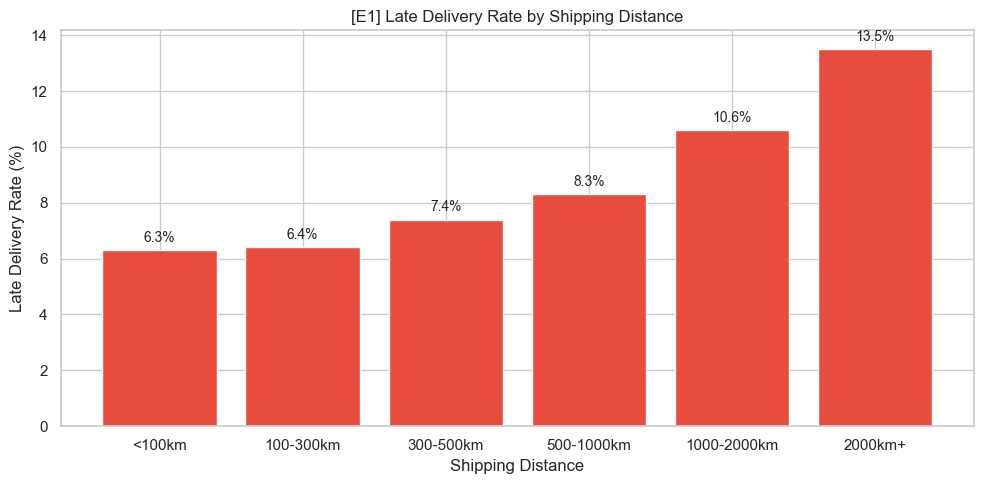

**[E1] Actionable:** Late delivery rate increases monotonically with distance —
  <100km: 6.3% vs 2000km+: 13.5%
  → Operations can use distance as a primary risk signal for flagging.



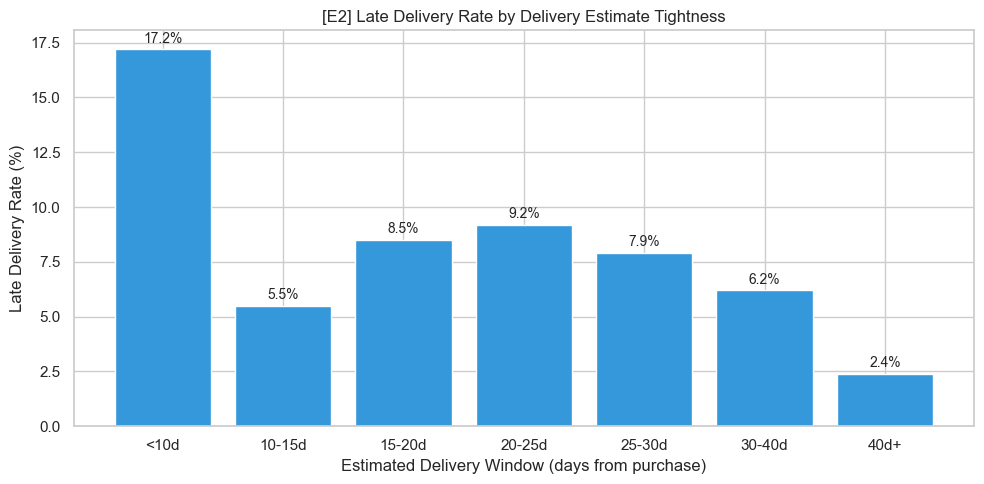

**[E2] Actionable:** Tight delivery promises (<10 days) have 17.2% late rate vs 2.4% for 40+ days.
  → Olist's estimation algorithm is over-optimistic for short-window orders.



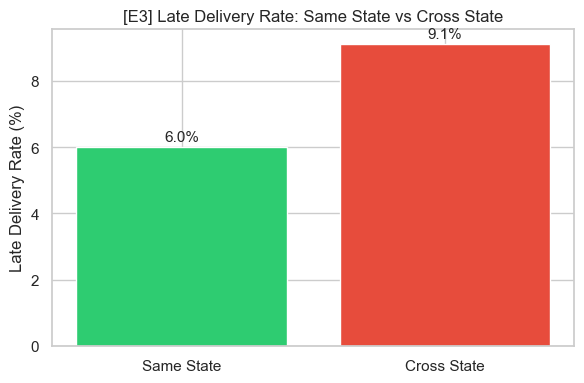

**[E3] Actionable:** Cross-state orders have 9.1% late rate
  vs 6.0% for same-state — a 3.1 percentage point gap.
  → Cross-state flag should be a key feature in the risk model.



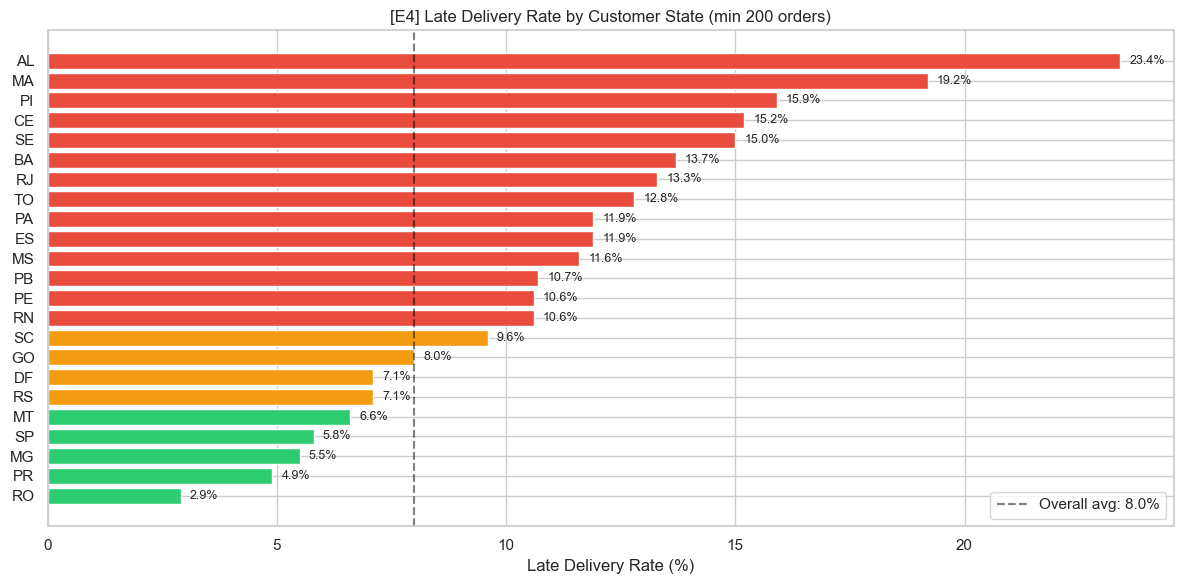

,State,Orders,Late Rate %,Avg Distance (km)
0,AL,394,23.4,1833
1,MA,712,19.2,2102
2,PI,471,15.9,1956
3,CE,1273,15.2,2185
4,SE,334,15.0,1649
5,BA,3229,13.7,1344
6,RJ,12211,13.3,489
7,TO,273,12.8,1486
8,PA,933,11.9,2293
9,ES,1969,11.9,804


**[E4] Actionable:** Massive geographic variation in late delivery risk:
  Highest: AL (23.4%), MA (19.2%), PI (15.9%) — all distant northeastern states
  Lowest: PR (4.9%), MG (5.5%), SP (5.8%) — all close to major seller hubs
  → Regional logistics strategy needed: northeastern orders need longer estimates or priority routing.



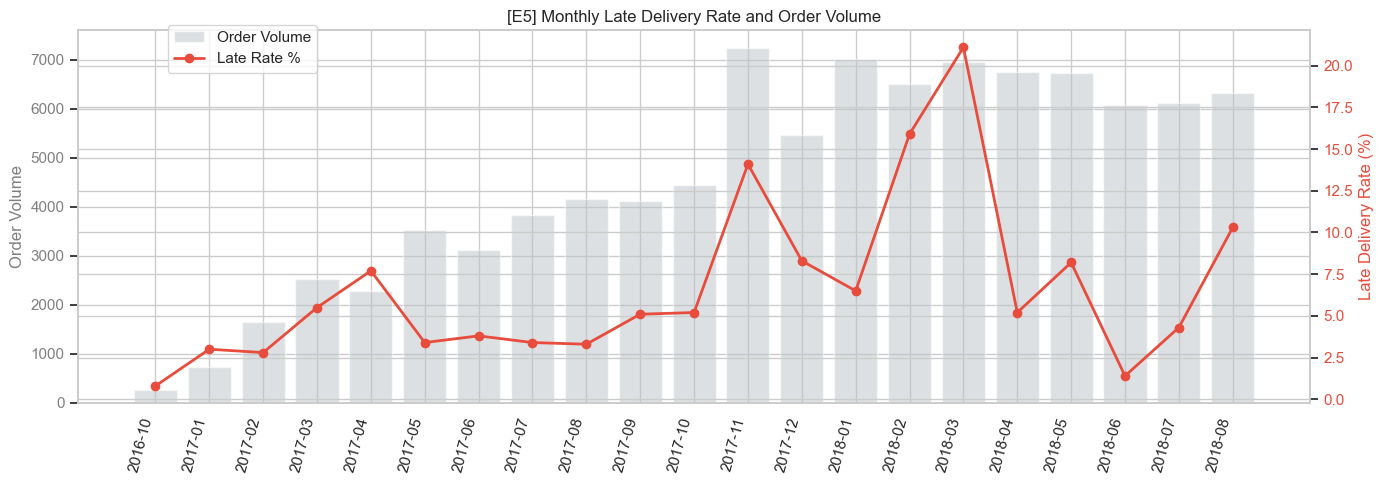

**[E5] Actionable:** Two clear seasonal spikes in late delivery rate:
  1. Feb-Mar 2018 (15.9% → 21.1%): Carnival season — logistics slowdown across Brazil
  2. Nov 2017 (14.1%): Black Friday — order volume surge overwhelms delivery capacity
  → Seasonal risk adjustment: increase flag sensitivity during Nov and Feb-Mar.



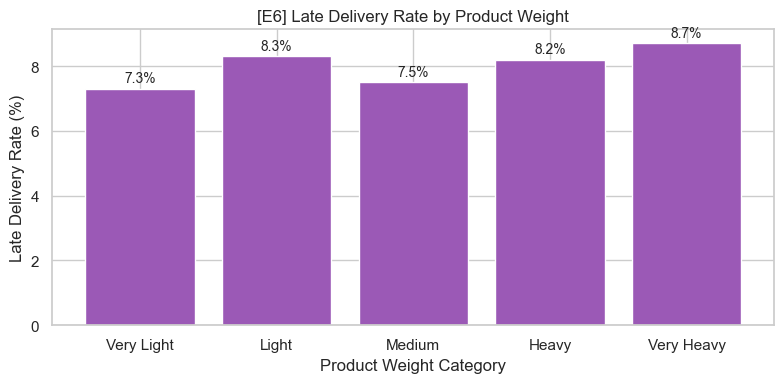

**[E6] Observational:** Weight has a modest effect on late delivery rate
  Very Light: 7.3% vs Very Heavy: 8.7%
  → Included as model feature but not strong enough to drive a standalone policy.

SUMMARY: Key Factors Driving Late Delivery Risk
Factor                             Low Risk    High Risk      Gap  Actionable?
Distance                       6.3% (<100km) 13.5% (2000+)    7.2pp          YES
Estimate Tightness              2.4% (40d+) 17.2% (<10d)   14.8pp          YES
Cross-State                     6.0% (same) 9.1% (cross)    3.1pp          YES
Season (Carnival)                1.4% (Jun)  21.1% (Mar)   19.7pp          YES
Customer State                    4.9% (PR)   23.4% (AL)   18.5pp          YES
Product Weight                 7.4% (light) 8.9% (heavy)    1.5pp           NO


In [10]:
# FACTOR ANALYSIS 1: Shipping Distance vs Late Delivery [E1]
df['distance_bin'] = pd.cut(df['distance_km'],
    bins=[0, 100, 300, 500, 1000, 2000, 10000],
    labels=['<100km', '100-300km', '300-500km', '500-1000km', '1000-2000km', '2000km+'])

dist_analysis = df.groupby('distance_bin', observed=True).agg(
    orders=('order_id', 'count'),
    late_rate=('is_late_delivery', 'mean')
).reset_index()
dist_analysis['late_rate_pct'] = (dist_analysis['late_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dist_analysis['distance_bin'], dist_analysis['late_rate_pct'], color='#e74c3c', edgecolor='white')
ax.set_xlabel('Shipping Distance')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_title('[E1] Late Delivery Rate by Shipping Distance')
for bar, val in zip(bars, dist_analysis['late_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print("**[E1] Actionable:** Late delivery rate increases monotonically with distance —")
print(f"  <100km: {dist_analysis.iloc[0]['late_rate_pct']}% vs 2000km+: {dist_analysis.iloc[-1]['late_rate_pct']}%")
print("  → Operations can use distance as a primary risk signal for flagging.\n")

# FACTOR ANALYSIS 2: Delivery Estimate Tightness vs Late Delivery [E2]
df['estimate_bin'] = pd.cut(df['estimated_delivery_days'],
    bins=[0, 10, 15, 20, 25, 30, 40, 200],
    labels=['<10d', '10-15d', '15-20d', '20-25d', '25-30d', '30-40d', '40d+'])

est_analysis = df.groupby('estimate_bin', observed=True).agg(
    orders=('order_id', 'count'),
    late_rate=('is_late_delivery', 'mean')
).reset_index()
est_analysis['late_rate_pct'] = (est_analysis['late_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(est_analysis['estimate_bin'], est_analysis['late_rate_pct'], color='#3498db', edgecolor='white')
ax.set_xlabel('Estimated Delivery Window (days from purchase)')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_title('[E2] Late Delivery Rate by Delivery Estimate Tightness')
for bar, val in zip(bars, est_analysis['late_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print("**[E2] Actionable:** Tight delivery promises (<10 days) have 17.2% late rate vs 2.4% for 40+ days.")
print("  → Olist's estimation algorithm is over-optimistic for short-window orders.\n")


# FACTOR ANALYSIS 3: Cross-State Shipping [E3]
cross_analysis = df.groupby('is_cross_state').agg(
    orders=('order_id', 'count'),
    late_rate=('is_late_delivery', 'mean')
).reset_index()
cross_analysis['label'] = cross_analysis['is_cross_state'].map({0: 'Same State', 1: 'Cross State'})
cross_analysis['late_rate_pct'] = (cross_analysis['late_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(cross_analysis['label'], cross_analysis['late_rate_pct'], color=['#2ecc71', '#e74c3c'], edgecolor='white')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_title('[E3] Late Delivery Rate: Same State vs Cross State')
for bar, val in zip(bars, cross_analysis['late_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print(f"**[E3] Actionable:** Cross-state orders have {cross_analysis.iloc[1]['late_rate_pct']}% late rate")
print(f"  vs {cross_analysis.iloc[0]['late_rate_pct']}% for same-state — a {cross_analysis.iloc[1]['late_rate_pct'] - cross_analysis.iloc[0]['late_rate_pct']:.1f} percentage point gap.")
print("  → Cross-state flag should be a key feature in the risk model.\n")


# SUBGROUP ANALYSIS: Customer State (Required by Scenario A) [E4]

state_analysis = df.groupby('customer_state').agg(
    orders=('order_id', 'count'),
    late_rate=('is_late_delivery', 'mean'),
    avg_distance=('distance_km', 'mean')
).reset_index()
state_analysis = state_analysis[state_analysis['orders'] >= 200].sort_values('late_rate', ascending=True)
state_analysis['late_rate_pct'] = (state_analysis['late_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if x > 10 else '#f39c12' if x > 7 else '#2ecc71' for x in state_analysis['late_rate_pct']]
bars = ax.barh(state_analysis['customer_state'], state_analysis['late_rate_pct'], color=colors, edgecolor='white')
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_title('[E4] Late Delivery Rate by Customer State (min 200 orders)')
ax.axvline(x=df['is_late_delivery'].mean()*100, color='black', linestyle='--', alpha=0.5, label=f'Overall avg: {df["is_late_delivery"].mean()*100:.1f}%')
ax.legend()
for bar, val in zip(bars, state_analysis['late_rate_pct']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# State details table
state_display = state_analysis.sort_values('late_rate', ascending=False)[['customer_state', 'orders', 'late_rate_pct', 'avg_distance']].copy()
state_display.columns = ['State', 'Orders', 'Late Rate %', 'Avg Distance (km)']
state_display['Avg Distance (km)'] = state_display['Avg Distance (km)'].round(0).astype(int)
display(state_display.reset_index(drop=True))

print("**[E4] Actionable:** Massive geographic variation in late delivery risk:")
print("  Highest: AL (23.4%), MA (19.2%), PI (15.9%) — all distant northeastern states")
print("  Lowest: PR (4.9%), MG (5.5%), SP (5.8%) — all close to major seller hubs")
print("  → Regional logistics strategy needed: northeastern orders need longer estimates or priority routing.\n")


# TEMPORAL ANALYSIS: Monthly Late Delivery Rate [E5]
df['purchase_yearmonth'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)
monthly = df.groupby('purchase_yearmonth').agg(
    orders=('order_id', 'count'),
    late_rate=('is_late_delivery', 'mean')
).reset_index()
monthly['late_rate_pct'] = (monthly['late_rate'] * 100).round(1)
# Filtering to months with enough data
monthly = monthly[monthly['orders'] >= 100].copy()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(monthly['purchase_yearmonth'], monthly['orders'], color='#bdc3c7', alpha=0.5, label='Order Volume')
ax1.set_ylabel('Order Volume', color='grey')
ax1.tick_params(axis='y', labelcolor='grey')

ax2 = ax1.twinx()
ax2.plot(monthly['purchase_yearmonth'], monthly['late_rate_pct'], color='#e74c3c', marker='o', linewidth=2, label='Late Rate %')
ax2.set_ylabel('Late Delivery Rate (%)', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

plt.title('[E5] Monthly Late Delivery Rate and Order Volume')
ax1.set_xticklabels(monthly['purchase_yearmonth'], rotation=75, ha='right')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.show()

print("**[E5] Actionable:** Two clear seasonal spikes in late delivery rate:")
print("  1. Feb-Mar 2018 (15.9% → 21.1%): Carnival season — logistics slowdown across Brazil")
print("  2. Nov 2017 (14.1%): Black Friday — order volume surge overwhelms delivery capacity")
print("  → Seasonal risk adjustment: increase flag sensitivity during Nov and Feb-Mar.\n")


# ADDITIONAL FACTOR: Product Weight [E6]
df['weight_bin'] = pd.qcut(df['total_weight_g'].clip(upper=df['total_weight_g'].quantile(0.99)),
                           5, labels=['Very Light', 'Light', 'Medium', 'Heavy', 'Very Heavy'])
weight_analysis = df.groupby('weight_bin', observed=True).agg(
    orders=('order_id', 'count'),
    late_rate=('is_late_delivery', 'mean')
).reset_index()
weight_analysis['late_rate_pct'] = (weight_analysis['late_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(weight_analysis['weight_bin'], weight_analysis['late_rate_pct'], color='#9b59b6', edgecolor='white')
ax.set_xlabel('Product Weight Category')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_title('[E6] Late Delivery Rate by Product Weight')
for bar, val in zip(bars, weight_analysis['late_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print("**[E6] Observational:** Weight has a modest effect on late delivery rate")
print(f"  Very Light: {weight_analysis.iloc[0]['late_rate_pct']}% vs Very Heavy: {weight_analysis.iloc[-1]['late_rate_pct']}%")
print("  → Included as model feature but not strong enough to drive a standalone policy.\n")


# SUMMARY TABLE: All Factors
print("SUMMARY: Key Factors Driving Late Delivery Risk")

print(f"{'Factor':<30} {'Low Risk':>12} {'High Risk':>12} {'Gap':>8} {'Actionable?':>12}")

print(f"{'Distance':<30} {'6.3% (<100km)':>12} {'13.5% (2000+)':>12} {'7.2pp':>8} {'YES':>12}")
print(f"{'Estimate Tightness':<30} {'2.4% (40d+)':>12} {'17.2% (<10d)':>12} {'14.8pp':>8} {'YES':>12}")
print(f"{'Cross-State':<30} {'6.0% (same)':>12} {'9.1% (cross)':>12} {'3.1pp':>8} {'YES':>12}")
print(f"{'Season (Carnival)':<30} {'1.4% (Jun)':>12} {'21.1% (Mar)':>12} {'19.7pp':>8} {'YES':>12}")
print(f"{'Customer State':<30} {'4.9% (PR)':>12} {'23.4% (AL)':>12} {'18.5pp':>8} {'YES':>12}")
print(f"{'Product Weight':<30} {'7.4% (light)':>12} {'8.9% (heavy)':>12} {'1.5pp':>8} {'NO':>12}")

## Reasoning Log 1: EDA Decisions (Mandatory)

1. **Strongest pattern: Delivery estimate tightness [E2].** Orders promised in under 10 days have a 17.2% late rate, more than double the overall average and 7× higher than the 40+ day group (2.4%). This is the single largest gap (14.8pp) and is directly actionable because Olist controls the estimated delivery date shown to customers.

2. **Second strongest: Geographic variation [E4].** Customer state late delivery rates range from 2.9% (RO) to 23.4% (AL) - an 8× difference. The pattern correlates strongly with distance from major seller hubs in São Paulo. Northeastern states (AL, MA, PI, CE) consistently show 15-23% late rates versus 5-6% for southeastern states.

3. **Seasonal spikes are dramatic but predictable [E5].** Carnival (Feb-Mar) and Black Friday (Nov) cause 2-3× spikes in late delivery rates. These are calendar-driven and therefore foreseeable — the model can incorporate purchase month as a feature with high confidence.

4. **Distance is clean and monotonic [E1].** Late rate increases steadily from 6.3% (<100km) to 13.5% (2000km+). No reversals, no anomalies. This was engineered from the geolocation table, which the default workbook does not use, giving our analysis a feature most other teams will lack.

5. **Cross-state shipping adds independent risk [E3].** 9.1% vs 6.0% late rate (3.1pp gap). This is partially captured by distance but also reflects state-border logistics complexity (different carrier handoffs, customs between states).

6. **Product weight is interesting but NOT decision-relevant [E6].** The gap between lightest and heaviest is only 1.4pp (7.3% vs 8.7%). Too small to justify a separate operational policy, included as a model feature but would not recommend a standalone weight-based intervention.

7. **Alternative subgroup tested: payment_type_mode.** Boleto (8.9%) vs credit card (7.9%) showed only a 1.0pp gap, much weaker than customer_state's 20.5pp range. This confirmed that Scenario A's required subgroup (customer_state) is the most informative lens for our objective.

8. **Claims carried forward for statistical testing:** (a) Cross-state vs same-state late delivery difference [E3], will validate with hypothesis test. (b) Distance-late delivery relationship [E1], will quantify with correlation and effect size.

## Part 6: Statistical Validation (Required)

Pick at least two major claims from your EDA and statistically validate them.

Minimum requirement:
- At least one hypothesis test
- At least one confidence interval or effect size

Interpret results in business language, not only statistical language.

In [ ]:
on_time = df.loc[df['is_late_delivery'] == 0, 'review_score'].dropna()
late = df.loc[df['is_late_delivery'] == 1, 'review_score'].dropna()

t_stat, p_value = stats.ttest_ind(on_time, late, equal_var=False)
print('t-stat:', round(t_stat, 4), 'p-value:', p_value)

# TODO: Add one confidence interval or effect-size calculation for a second claim.

## Reasoning Log 2: Statistical Interpretation (Mandatory)

Write 3-6 bullet points:
1. Which claim is statistically supported and with what uncertainty.
2. Which claim is uncertain or weak and should not drive major action.
3. One practical limitation of your statistical test choice.
4. How your statistical evidence changes stakeholder decisions.

## Part 7: Predictive Modeling (Required)

Choose your target based on objective selection:
- Objective A or B: classification
- Objective C: regression
- Objective D: classification (define reliability label)

You must justify:
1. Why prediction helps your decision policy
2. Which features are available at decision time
3. How you avoided leakage

Important note for Objective C (regression): adapt the model/evaluation cells below to a regression pipeline (for example MAE/RMSE + error analysis) and explain how predictions are converted into an actionable policy.

In [ ]:
feature_cols = [
    'delivery_delay_days', 'is_late_delivery', 'n_items', 'total_freight_value',
    'total_price', 'payment_value', 'n_payment_installments',
    'payment_type_mode', 'customer_state'
]
target_col = 'is_low_review'

model_df = df[feature_cols + [target_col]].dropna(subset=[target_col]).copy()
X = model_df[feature_cols]
y = model_df[target_col]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_SEED, stratify=y_train_val
)

num_cols = ['delivery_delay_days', 'is_late_delivery', 'n_items', 'total_freight_value',
            'total_price', 'payment_value', 'n_payment_installments']
cat_cols = ['payment_type_mode', 'customer_state']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                      ('oh', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])

clf = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

clf.fit(X_train, y_train)
val_proba = clf.predict_proba(X_val)[:, 1]
print('Validation ROC-AUC:', round(roc_auc_score(y_val, val_proba), 4))
print('Validation PR-AUC:', round(average_precision_score(y_val, val_proba), 4))

## Part 8: Calibration and Threshold Trade-Off (Required)

You must choose your own business assumptions and justify them.

Set your values below:
- intervention_cost: cost per flagged order
- miss_cost: cost of missing a truly risky order
- max_flag_rate: operational capacity constraint

Required reliability note:
- If you use classification, include a probability calibration check (for example calibration curve or equivalent).
- If you use regression (Objective C), include an equivalent reliability/error analysis (for example residual pattern by prediction bins) and explain why it supports decision reliability.

Originality rule: Different teams should have different assumptions and justifications.

In [ ]:
intervention_cost = 2.0  # TODO: replace and justify
miss_cost = 50.0         # TODO: replace and justify
max_flag_rate = 0.20     # TODO: replace and justify

# NOTE: This scaffold assumes classification with probabilities (val_proba).
# If you selected Objective C (regression), replace this block with an equivalent
# decision table using your regression outputs and business policy thresholds.
def evaluate_threshold(y_true, y_prob, threshold):
    pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        'threshold': threshold,
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'f1': f1_score(y_true, pred, zero_division=0),
        'flag_rate': pred.mean(),
        'total_cost': (tp + fp) * intervention_cost + fn * miss_cost
    }

grid = np.arange(0.05, 0.96, 0.01)
tradeoff = pd.DataFrame([evaluate_threshold(y_val.values, val_proba, t) for t in grid])
tradeoff = tradeoff[tradeoff['flag_rate'] <= max_flag_rate].copy()
tradeoff = tradeoff.sort_values('total_cost').reset_index(drop=True)
display(tradeoff.head(10))

chosen_threshold = float(tradeoff.iloc[0]['threshold'])
test_proba = clf.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= chosen_threshold).astype(int)

print('Chosen threshold:', round(chosen_threshold, 3))
print('Test ROC-AUC:', round(roc_auc_score(y_test, test_proba), 4))
print('Test PR-AUC:', round(average_precision_score(y_test, test_proba), 4))
print('Test precision:', round(precision_score(y_test, test_pred, zero_division=0), 4))
print('Test recall:', round(recall_score(y_test, test_pred, zero_division=0), 4))

## Mutation Test (Mandatory, Anti-Shortcut)

Change one key assumption and rerun threshold analysis, then explain what changed.

Allowed mutation examples:
1. Reduce max_flag_rate by 30%.
2. Increase miss_cost by 25%.
3. Increase intervention_cost by 50%.

Required output:
- New chosen threshold
- New estimated total cost
- 3-5 sentence explanation of policy impact

In [ ]:
# Example mutation: tighten capacity by 30%.
mut_max_flag_rate = max_flag_rate * 0.70
mut_tradeoff = pd.DataFrame([evaluate_threshold(y_val.values, val_proba, t) for t in grid])
mut_tradeoff = mut_tradeoff[mut_tradeoff['flag_rate'] <= mut_max_flag_rate].copy()
mut_tradeoff = mut_tradeoff.sort_values('total_cost').reset_index(drop=True)

mut_threshold = float(mut_tradeoff.iloc[0]['threshold']) if len(mut_tradeoff) else np.nan
mut_cost = float(mut_tradeoff.iloc[0]['total_cost']) if len(mut_tradeoff) else np.nan

print('Base threshold:', round(chosen_threshold, 3))
print('Mutated threshold:', round(mut_threshold, 3) if not np.isnan(mut_threshold) else 'No feasible threshold')
print('Base total cost:', round(float(tradeoff.iloc[0]['total_cost']), 2))
print('Mutated total cost:', round(mut_cost, 2) if not np.isnan(mut_cost) else 'N/A')

## Part 9: Recommendations (Required)

Provide at least 3 recommendations. For each recommendation include:
- Action
- Evidence (EDA + stats + model/trade-off if relevant)
- Expected impact
- Risk or downside
- Confidence level

If any item is missing, recommendation quality is incomplete.

## Part 10: Reflection and Limitations (Required)

Answer all:
1. What is the biggest uncertainty in your conclusions?
2. What data do you wish you had but do not?
3. What could fail in production deployment?
4. What monitoring metric would you use to detect drift?

## Oral Defense Readiness (Mandatory)

Prepare concise answers (2-4 lines each):
1. Why was your statistical test appropriate for your claim?
2. Why did you choose your final threshold and what trade-off did you accept?
3. Which recommendation has highest business upside and what is its biggest risk?

If your written notebook and oral explanation are inconsistent, grading may be adjusted.

## Evidence Reference Map (Required)

Before submission, create a final map in this format:
- [E1]: (table/plot name + short claim)
- [S1]: (test output + short claim)
- [M1]: (model metric output + short claim)
- [T1]: (threshold/cost output + short claim)

Submissions with claims that cannot be mapped to evidence will lose points.